# 🏙️ YOLOv8 Urban Object Detection

**Recreating [YOLOv7 Urban Object Detection](https://www.kaggle.com/code/evilspirit05/yolov7-urban-object-detection-pytorch) using YOLOv8**

---

## 📋 Project Overview

This notebook trains a **YOLOv8** model for detecting urban objects such as cars, people, bicycles, buses, traffic lights, stop signs, potholes, and more.

### Dataset: Senior Design VIAD v4 (Roboflow)
- **38,922 images** (300×300) with **65,465 annotations**
- **37 classes** of urban objects
- Split: Train (32,511) | Valid (4,246) | Test (2,165)
- Format: COCO JSON → converted to YOLO format in this notebook

### Pipeline
1. Install dependencies (with CUDA GPU support)
2. Convert COCO annotations → YOLO format
3. Exploratory Data Analysis (EDA)
4. Train YOLOv8 model (GPU-accelerated)
5. Evaluate & visualize results
6. Run inference on test images
7. Export trained model

In [ ]:
# ============================================================
# Cell 1: Install Dependencies (with CUDA GPU support)
# ============================================================
# ⚠️ IMPORTANT: After this cell finishes, RESTART THE KERNEL!
#    Jupyter menu: Kernel → Restart Kernel
#    Then skip this cell and run from Cell 2 onwards.
# ============================================================

import sys

# Use sys.executable to ensure pip installs into THIS kernel's Python
# (not some other Python on your PATH)
print(f'Kernel Python: {sys.executable}')
print()

# Step 1: Uninstall CPU-only PyTorch first
!{sys.executable} -m pip uninstall torch torchvision torchaudio -y -q

# Step 2: Install CUDA-enabled PyTorch (cu128 works with your CUDA 13.1 driver)
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128 -q

# Step 3: Install remaining dependencies
!{sys.executable} -m pip install ultralytics opencv-python matplotlib seaborn pyyaml -q

print()
print('=' * 60)
print('  ✅ Installation complete!')
print()
print('  🔄 NOW RESTART THE KERNEL:')
print('     Jupyter menu → Kernel → Restart Kernel')
print('     Then run from Cell 2 (skip this cell).')
print('=' * 60)

In [1]:
# ============================================================
# Cell 2: Import Libraries & Verify GPU
# ============================================================
# Run this AFTER restarting the kernel (if you ran Cell 1)
# ============================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
import json
import glob
import random
import shutil
import yaml
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from IPython.display import display, Image as IPImage, clear_output

import torch
from ultralytics import YOLO

# Set plot style
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Reproducibility
random.seed(42)
np.random.seed(42)

# --- GPU Verification ---
print('=' * 60)
print(f'  Kernel Python    : {sys.executable}')
print(f'  PyTorch version  : {torch.__version__}')
print(f'  CUDA available   : {torch.cuda.is_available()}')
print(f'  CUDA version     : {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'  GPU              : {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'  GPU Memory       : {mem:.1f} GB')
    print(f'  ✅ Training will use GPU acceleration!')
else:
    print(f'  ⚠️  GPU not detected!')
    print(f'  Ensure you ran Cell 1 and restarted the kernel.')
    print(f'  PyTorch build should show "+cu128" not "+cpu".')
print('=' * 60)
print(f'\n📁 Working directory: {os.getcwd()}')

  Kernel Python    : C:\Users\devak\anaconda3\python.exe
  PyTorch version  : 2.11.0+cu128
  CUDA available   : True
  CUDA version     : 12.8
  GPU              : NVIDIA GeForce GTX 1650
  GPU Memory       : 4.0 GB
  ✅ Training will use GPU acceleration!

📁 Working directory: C:\Users\devak\Documents\Custom_Object_Detection


In [2]:
# ============================================================
# Cell 3: Convert COCO Annotations → YOLO Format + data.yaml
# ============================================================

DATASET_DIR = Path('dataset')
YOLO_DIR = Path('yolo_dataset')
SPLITS = ['train', 'valid', 'test']

def coco_to_yolo(coco_json_path, images_dir, output_images_dir, output_labels_dir):
    """
    Convert COCO format annotations to YOLO format.
    YOLO format: <class_id> <x_center> <y_center> <width> <height> (all normalized 0-1)
    """
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)
    
    # Build lookup: image_id -> image_info
    images_info = {img['id']: img for img in coco_data['images']}
    
    # Build lookup: image_id -> list of annotations
    img_annotations = defaultdict(list)
    for ann in coco_data['annotations']:
        img_annotations[ann['image_id']].append(ann)
    
    # Create output directories
    output_images_dir.mkdir(parents=True, exist_ok=True)
    output_labels_dir.mkdir(parents=True, exist_ok=True)
    
    converted = 0
    skipped = 0
    
    for img_id, img_info in images_info.items():
        img_filename = img_info['file_name']
        img_w = img_info['width']
        img_h = img_info['height']
        
        # Copy image
        src_img = images_dir / img_filename
        dst_img = output_images_dir / img_filename
        
        if not src_img.exists():
            skipped += 1
            continue
        
        # Only copy if not already there
        if not dst_img.exists():
            shutil.copy2(src_img, dst_img)
        
        # Write YOLO label file
        label_filename = Path(img_filename).stem + '.txt'
        label_path = output_labels_dir / label_filename
        
        annotations = img_annotations.get(img_id, [])
        
        with open(label_path, 'w') as lf:
            for ann in annotations:
                cat_id = ann['category_id']
                # COCO bbox: [x_min, y_min, width, height]
                x_min, y_min, bbox_w, bbox_h = ann['bbox']
                
                # Convert to YOLO format: center_x, center_y, width, height (normalized)
                x_center = (x_min + bbox_w / 2.0) / img_w
                y_center = (y_min + bbox_h / 2.0) / img_h
                norm_w = bbox_w / img_w
                norm_h = bbox_h / img_h
                
                # Clamp values to [0, 1]
                x_center = max(0, min(1, x_center))
                y_center = max(0, min(1, y_center))
                norm_w = max(0, min(1, norm_w))
                norm_h = max(0, min(1, norm_h))
                
                lf.write(f'{cat_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n')
        
        converted += 1
    
    return converted, skipped, coco_data['categories']


# --- Run conversion for each split ---
print('🔄 Converting COCO annotations to YOLO format...\n')
all_categories = None

for split in SPLITS:
    coco_json = DATASET_DIR / split / '_annotations.coco.json'
    images_dir = DATASET_DIR / split
    
    out_images = YOLO_DIR / 'images' / split
    out_labels = YOLO_DIR / 'labels' / split
    
    if not coco_json.exists():
        print(f'  ⚠️  {split}: annotation file not found, skipping')
        continue
    
    converted, skipped, categories = coco_to_yolo(coco_json, images_dir, out_images, out_labels)
    all_categories = categories
    print(f'  ✅ {split}: {converted} images converted, {skipped} skipped')


# --- Create data.yaml ---
class_names = [cat['name'] for cat in sorted(all_categories, key=lambda x: x['id'])]
num_classes = len(class_names)

data_yaml = {
    'path': str(YOLO_DIR.resolve()),
    'train': 'images/train',
    'val': 'images/valid',
    'test': 'images/test',
    'nc': num_classes,
    'names': class_names
}

yaml_path = Path('data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'\n📄 data.yaml created at: {yaml_path.resolve()}')
print(f'   Classes ({num_classes}): {class_names}')
print(f'\n✅ Dataset conversion complete!')

🔄 Converting COCO annotations to YOLO format...

  ✅ train: 32511 images converted, 0 skipped
  ✅ valid: 4246 images converted, 0 skipped
  ✅ test: 2165 images converted, 0 skipped

📄 data.yaml created at: C:\Users\devak\Documents\Custom_Object_Detection\data.yaml
   Classes (37): ['cars-bikes-people', 'Bus', 'Bushes', 'Person', 'Truck', 'backpack', 'bench', 'bicycle', 'boat', 'branch', 'car', 'chair', 'clock', 'crosswalk', 'door', 'elevator', 'fire_hydrant', 'green_light', 'gun', 'handbag', 'motorcycle', 'person', 'pothole', 'rat', 'red_light', 'scooter', 'sheep', 'stairs', 'stop_sign', 'suitcase', 'traffic light', 'traffic_cone', 'train', 'tree', 'truck', 'umbrella', 'yellow_light']

✅ Dataset conversion complete!


📊 DATASET STATISTICS
   train: 32,511 images |  54,480 objects | 1.7 obj/img
   valid:  4,246 images |   7,255 objects | 1.7 obj/img
    test:  2,165 images |   3,730 objects | 1.7 obj/img

📊 Generating class distribution plot...


C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:65: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:66: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\devak\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


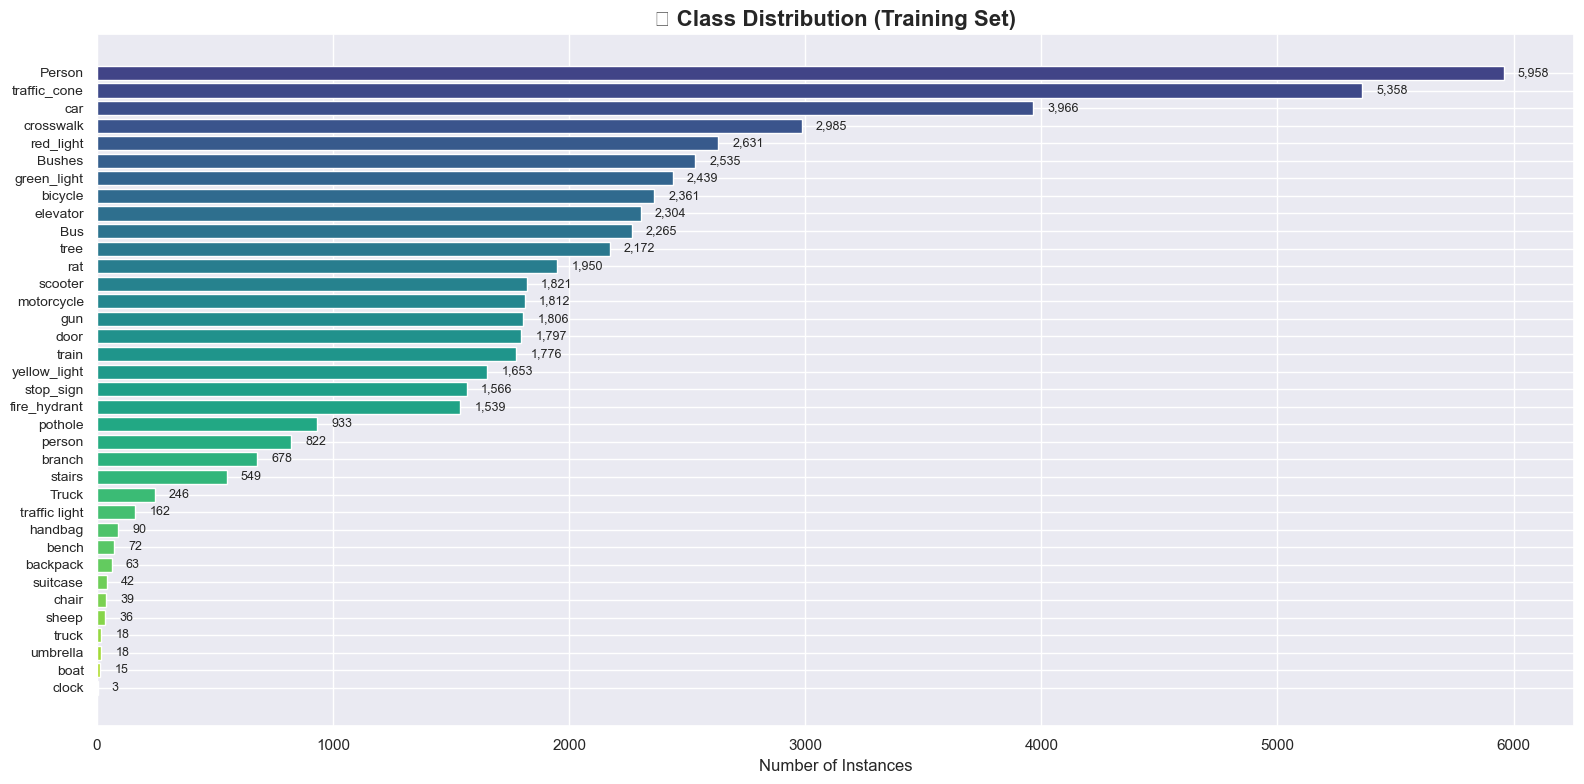


🖼️ Displaying sample images with bounding boxes...


C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:121: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:121: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:122: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) Arial.
  plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:122: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
C:\Users\devak\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\devak\anaconda3\Lib\site-pa

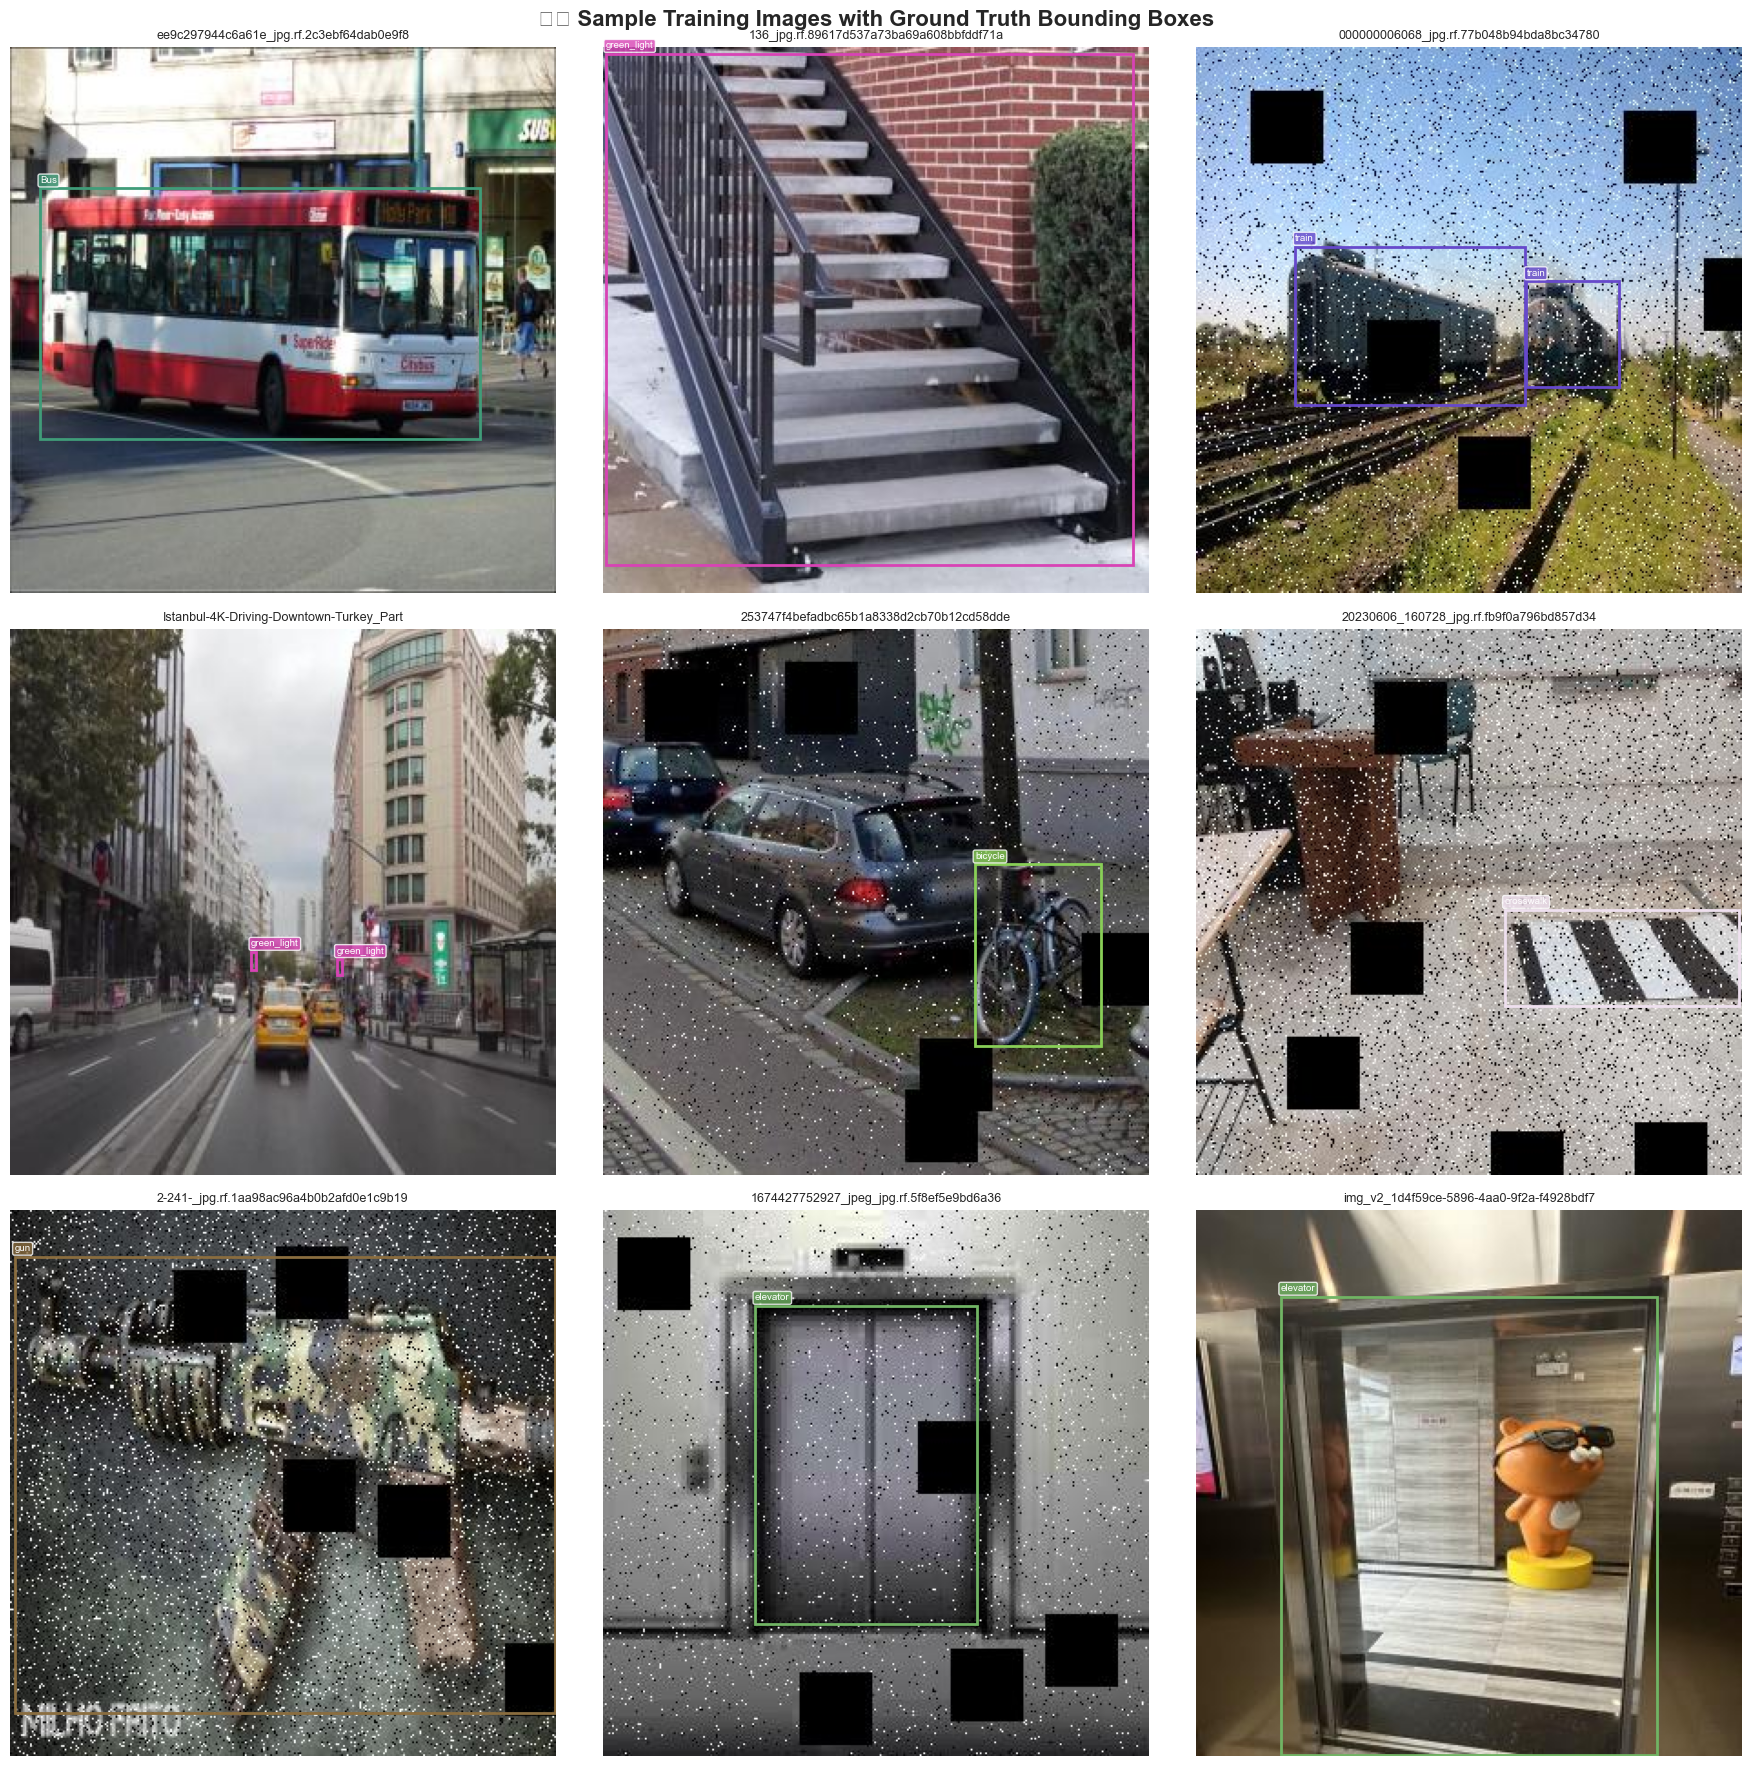


📏 Analyzing bounding box size distribution...


C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:158: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\devak\AppData\Local\Temp\ipykernel_22456\1898716308.py:159: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.savefig('bbox_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\devak\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


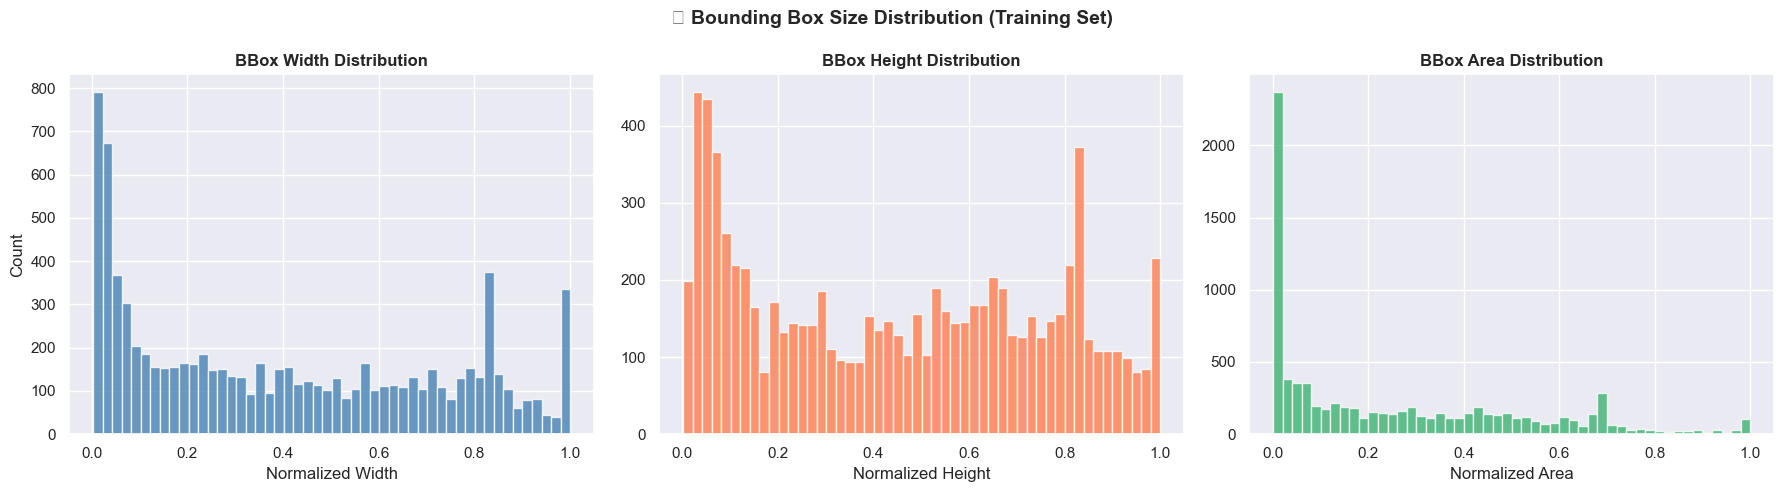


✅ EDA complete!


In [3]:
# ============================================================
# Cell 4: Exploratory Data Analysis (EDA)
# ============================================================

# --- 4a. Dataset Statistics ---
print('=' * 60)
print('📊 DATASET STATISTICS')
print('=' * 60)

for split in SPLITS:
    img_dir = YOLO_DIR / 'images' / split
    lbl_dir = YOLO_DIR / 'labels' / split
    
    num_imgs = len(list(img_dir.glob('*.jpg'))) if img_dir.exists() else 0
    num_lbls = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    
    # Count total objects
    total_objects = 0
    if lbl_dir.exists():
        for lbl_file in lbl_dir.glob('*.txt'):
            with open(lbl_file) as f:
                total_objects += len(f.readlines())
    
    avg_obj = total_objects / num_imgs if num_imgs > 0 else 0
    print(f'  {split:>6s}: {num_imgs:>6,} images | {total_objects:>7,} objects | {avg_obj:.1f} obj/img')

print()


# --- 4b. Class Distribution ---
print('📊 Generating class distribution plot...')
class_counts = Counter()

train_labels_dir = YOLO_DIR / 'labels' / 'train'
for lbl_file in train_labels_dir.glob('*.txt'):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

# Map class IDs to names
with open('data.yaml') as f:
    data_cfg = yaml.safe_load(f)
names = data_cfg['names']

sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
class_labels = [names[cid] for cid, _ in sorted_classes]
class_values = [cnt for _, cnt in sorted_classes]

fig, ax = plt.subplots(figsize=(16, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(class_labels)))
bars = ax.barh(range(len(class_labels)), class_values, color=colors)
ax.set_yticks(range(len(class_labels)))
ax.set_yticklabels(class_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Number of Instances', fontsize=12)
ax.set_title('📊 Class Distribution (Training Set)', fontsize=16, fontweight='bold')

# Add count labels on bars
for i, (bar, val) in enumerate(zip(bars, class_values)):
    ax.text(bar.get_width() + max(class_values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 4c. Sample Images with Bounding Boxes ---
print('\n🖼️ Displaying sample images with bounding boxes...')

# Color palette for classes
np.random.seed(42)
class_colors = {i: tuple(np.random.randint(50, 255, 3).tolist()) for i in range(len(names))}

train_images_dir = YOLO_DIR / 'images' / 'train'
sample_images = random.sample(list(train_images_dir.glob('*.jpg')), min(9, len(list(train_images_dir.glob('*.jpg')))))

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    # Read corresponding label
    label_path = train_labels_dir / (img_path.stem + '.txt')
    
    ax = axes[idx]
    ax.imshow(img)
    
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    
                    # Convert normalized YOLO to pixel coordinates
                    x1 = int((xc - bw / 2) * w)
                    y1 = int((yc - bh / 2) * h)
                    box_w = int(bw * w)
                    box_h = int(bh * h)
                    
                    color = [c / 255.0 for c in class_colors[cls_id]]
                    rect = patches.Rectangle((x1, y1), box_w, box_h,
                                             linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    
                    cls_name = names[cls_id] if cls_id < len(names) else str(cls_id)
                    ax.text(x1, y1 - 3, cls_name, fontsize=7, color='white',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))
    
    ax.set_title(img_path.name[:40], fontsize=9)
    ax.axis('off')

plt.suptitle('🖼️ Sample Training Images with Ground Truth Bounding Boxes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 4d. Bounding Box Size Distribution ---
print('\n📏 Analyzing bounding box size distribution...')
bbox_widths = []
bbox_heights = []
bbox_areas = []

for lbl_file in list(train_labels_dir.glob('*.txt'))[:5000]:  # Sample for speed
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                bw, bh = float(parts[3]), float(parts[4])
                bbox_widths.append(bw)
                bbox_heights.append(bh)
                bbox_areas.append(bw * bh)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(bbox_widths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('BBox Width Distribution', fontweight='bold')
axes[0].set_xlabel('Normalized Width')
axes[0].set_ylabel('Count')

axes[1].hist(bbox_heights, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('BBox Height Distribution', fontweight='bold')
axes[1].set_xlabel('Normalized Height')

axes[2].hist(bbox_areas, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('BBox Area Distribution', fontweight='bold')
axes[2].set_xlabel('Normalized Area')

plt.suptitle('📏 Bounding Box Size Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bbox_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ EDA complete!')

---
## 🧠 Model Setup

We use **YOLOv8n (nano)** — the smallest and fastest YOLOv8 variant — pre-trained on COCO.

| Model | Params | mAP@50 | Speed (ms) |
|-------|--------|--------|------------|
| YOLOv8n | 3.2M | 37.3 | 1.21 |
| YOLOv8s | 11.2M | 44.9 | 1.40 |
| YOLOv8m | 25.9M | 50.2 | 2.63 |
| YOLOv8l | 43.7M | 52.9 | 3.84 |

**Transfer Learning**: Starting from COCO-pretrained weights significantly accelerates convergence on our 37-class urban dataset.

**GPU Acceleration**: Training uses your **NVIDIA GeForce GTX 1650 (4GB VRAM)** via CUDA for ~10-20x faster training vs CPU.

> 💡 **Tip**: To improve accuracy, swap `yolov8n.pt` with `yolov8s.pt` or `yolov8m.pt` below.  
> ⚠️ **GTX 1650 (4GB)**: If you get OOM errors, reduce `batch` from 16 to 8.

In [4]:
import sys
!{sys.executable} -m pip install -U ultralytics -q

In [5]:
# ============================================================
# Cell 6: Load YOLOv8 Model
# ============================================================

# Load YOLOv8 Nano with pretrained COCO weights
model = YOLO('yolov8n.pt')

print('✅ YOLOv8n model loaded successfully!')
print(f'   Model type: {model.type}')
print(f'   Task: {model.task}')
print(f'   Device: {"CUDA (GPU)" if torch.cuda.is_available() else "CPU"}')

✅ YOLOv8n model loaded successfully!
   Model type: <bound method Module.type of YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
     

In [ ]:
# ============================================================
# Cell 7: Train the Model (GPU-Accelerated)
# ============================================================

# Training configuration
EPOCHS = 25         # Increase to 50-100 for better results
IMG_SIZE = 640      # Standard YOLO input size
BATCH_SIZE = 16     # Reduce to 8 if OOM on GTX 1650 (4GB VRAM)
PROJECT = 'runs/detect'
NAME = 'urban_detection'

# Auto-select device: 0 = first GPU, 'cpu' = CPU
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print('🚀 Starting YOLOv8 training...')
print(f'   Epochs: {EPOCHS}')
print(f'   Image Size: {IMG_SIZE}')
print(f'   Batch Size: {BATCH_SIZE}')
print(f'   Device: {"GPU " + torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU"}')
print(f'   Project: {PROJECT}/{NAME}')
print('=' * 60)

results = model.train(
    data='data.yaml',
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,       # Use GPU!
    project=PROJECT,
    name=NAME,
    exist_ok=True,
    plots=True,
    patience=10,         # Early stopping patience
    save=True,           # Save checkpoints
    save_period=5,       # Save every 5 epochs
    verbose=True,
    pretrained=True,
    optimizer='auto',
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    close_mosaic=10,
    seed=42
)

print('\n✅ Training complete!')
print(f'   Best weights: {PROJECT}/{NAME}/weights/best.pt')

🚀 Starting YOLOv8 training...
   Epochs: 25
   Image Size: 640
   Batch Size: 16
   Device: GPU NVIDIA GeForce GTX 1650
   Project: runs/detect/urban_detection
Ultralytics 8.4.53  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mome

In [ ]:
# ============================================================
# Cell 8: Visualize Training Results
# ============================================================

results_dir = Path(f'{PROJECT}/{NAME}')

# Display training plots generated by Ultralytics
plot_files = [
    ('results.png', '📈 Training & Validation Metrics'),
    ('confusion_matrix.png', '🔄 Confusion Matrix'),
    ('confusion_matrix_normalized.png', '🔄 Normalized Confusion Matrix'),
    ('F1_curve.png', '📊 F1 Score Curve'),
    ('P_curve.png', '📊 Precision Curve'),
    ('R_curve.png', '📊 Recall Curve'),
    ('PR_curve.png', '📊 Precision-Recall Curve'),
    ('labels.jpg', '🏷️ Label Distribution'),
    ('labels_correlogram.jpg', '📐 Label Correlogram'),
]

for filename, title in plot_files:
    filepath = results_dir / filename
    if filepath.exists():
        print(f'\n{title}')
        print('-' * 50)
        img = Image.open(filepath)
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f'  ⚠️ {filename} not found')

# Also display training batch visualizations if available
for batch_file in sorted(results_dir.glob('train_batch*.jpg'))[:3]:
    print(f'\n🖼️ {batch_file.name}')
    img = Image.open(batch_file)
    fig, ax = plt.subplots(figsize=(14, 14))
    ax.imshow(img)
    ax.set_title(f'Training Batch: {batch_file.name}', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print('\n✅ Training results visualization complete!')

In [ ]:
# ============================================================
# Cell 9: Evaluate on Validation Set
# ============================================================

# Load best weights
best_model = YOLO(f'{PROJECT}/{NAME}/weights/best.pt')

print('📊 Evaluating model on validation set...\n')

DEVICE = 0 if torch.cuda.is_available() else 'cpu'

metrics = best_model.val(
    data='data.yaml',
    split='val',
    imgsz=640,
    batch=16,
    device=DEVICE,
    verbose=True,
    plots=True
)

print('\n' + '=' * 60)
print('📊 VALIDATION RESULTS')
print('=' * 60)
print(f'  mAP@0.5       : {metrics.box.map50:.4f}')
print(f'  mAP@0.5:0.95  : {metrics.box.map:.4f}')
print(f'  Precision      : {metrics.box.mp:.4f}')
print(f'  Recall         : {metrics.box.mr:.4f}')
print('=' * 60)

# Per-class AP
print('\n📋 Per-Class AP@0.5:')
print('-' * 40)
for i, ap in enumerate(metrics.box.ap50):
    if i < len(names):
        print(f'  {names[i]:<20s}: {ap:.4f}')

In [ ]:
# ============================================================
# Cell 10: Run Inference on Test Images
# ============================================================

# Load best model
best_model = YOLO(f'{PROJECT}/{NAME}/weights/best.pt')

# Get test images
test_images_dir = YOLO_DIR / 'images' / 'test'
test_images = list(test_images_dir.glob('*.jpg'))
sample_test = random.sample(test_images, min(12, len(test_images)))

DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print(f'🔍 Running inference on {len(sample_test)} test images (device: {"GPU" if DEVICE == 0 else "CPU"})...\n')

# Run prediction
results = best_model.predict(
    source=[str(img) for img in sample_test],
    conf=0.25,
    iou=0.45,
    imgsz=640,
    device=DEVICE,
    save=True,
    save_txt=True,
    project=PROJECT,
    name='test_predictions',
    exist_ok=True
)

# Display predictions
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

for idx, result in enumerate(results):
    if idx >= 12:
        break
    
    ax = axes[idx]
    
    # Get the plotted image from result
    annotated_img = result.plot()  # Returns BGR numpy array
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(annotated_img)
    
    # Count detections
    num_detections = len(result.boxes) if result.boxes is not None else 0
    ax.set_title(f'{Path(result.path).name[:30]}\n({num_detections} detections)', fontsize=9)
    ax.axis('off')

# Hide empty subplots
for idx in range(len(results), 12):
    axes[idx].axis('off')

plt.suptitle('🔍 YOLOv8 Predictions on Test Images', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Inference complete!')
print(f'   Predictions saved to: {PROJECT}/test_predictions/')

In [ ]:
# ============================================================
# Cell 11: Export Model
# ============================================================

best_model = YOLO(f'{PROJECT}/{NAME}/weights/best.pt')

print('📦 Exporting model to ONNX format...\n')

# Export to ONNX (most portable format)
onnx_path = best_model.export(format='onnx', imgsz=640, simplify=True)

print(f'\n✅ Model exported successfully!')
print(f'   ONNX model: {onnx_path}')
print(f'   PyTorch best weights: {PROJECT}/{NAME}/weights/best.pt')
print(f'   PyTorch last weights: {PROJECT}/{NAME}/weights/last.pt')

print('\n' + '=' * 60)
print('🎉 PROJECT COMPLETE!')
print('=' * 60)
print(f'''
Summary:
  📊 Dataset: Senior Design VIAD v4 (38,922 images, 37 classes)
  🧠 Model: YOLOv8n (Nano)
  🖥️ Device: {'NVIDIA ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}
  📈 Training: {EPOCHS} epochs @ {IMG_SIZE}px
  💾 Weights: {PROJECT}/{NAME}/weights/best.pt
  📦 Export: {onnx_path}

Next Steps:
  • Increase epochs (50-100) for better accuracy
  • Try larger models (yolov8s, yolov8m) for higher mAP
  • Fine-tune hyperparameters with model.tune()
  • Deploy using the ONNX model with OpenCV DNN or ONNX Runtime
''')